# 🔍 Deepfake Detector v3 — Fine-tune on FaceForensics++
### Continues from your v2 model (already trained on 140k + Celeb-DF)

## 📦 Datasets to add before running

Add ALL of these in Kaggle via **+ Add Data**:

| Dataset | Kaggle Link | Size | What it adds |
|---|---|---|---|
| FF++ C23 (videos) | `kaggle datasets add xdxd003/ff-c23` | ~15GB | 6 manipulation methods |
| Your v2 model | Upload `deepfake_detector_v2_final.pth` as dataset | 75MB | Starting checkpoint |
| 140k faces | `xhlulu/140k-real-and-fake-faces` | 2.5GB | Original dataset |
| Celeb-DF v2 | `pranabr0y/celebdf-v2image-dataset` | ~1GB | Face-swap fakes |

## 🎯 What this notebook does
1. Extracts face crops from FF++ videos (5 frames/video × 7000 videos = ~35K faces)
2. Combines ALL datasets: 140k + Celeb-DF + FF++ = ~240K images
3. Fine-tunes your v2 model on the combined set
4. Evaluates and exports the final v3 model

## 📊 Expected improvement
Your v2 model learned: GAN fakes + face-swap fakes
Your v3 model will learn: GAN + face-swap + reenactment + neural texture manipulation
= **the 4 major deepfake categories**


## ✅ Cell 1 — Install Libraries

In [1]:
!pip install -q timm grad-cam albumentations
# Note: facenet-pytorch NOT installed here to avoid Pillow conflicts
# Face extraction uses OpenCV + dlib instead
!pip install -q dlib
print('✅ Libraries installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 62.7 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 102.8 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 

## ✅ Cell 2 — Setup Paths

In [2]:
import os

WORKING_DIR    = '/kaggle/working'
MODEL_DIR      = os.path.join(WORKING_DIR, 'models')
HISTORY_DIR    = os.path.join(WORKING_DIR, 'history')
RESULTS_DIR    = os.path.join(WORKING_DIR, 'results')
CHECKPOINT_DIR = os.path.join(WORKING_DIR, 'checkpoints')
EXTRACTED_DIR  = os.path.join(WORKING_DIR, 'ffpp_extracted')

for d in [MODEL_DIR, HISTORY_DIR, RESULTS_DIR, CHECKPOINT_DIR, EXTRACTED_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Print all available datasets ──────────────────────────────────
print('Available input datasets:')
for root, dirs, files in os.walk('/kaggle/input'):
    depth = root.replace('/kaggle/input', '').count(os.sep)
    if depth < 3:
        n = len(files)
        indent = '  ' * depth
        name = os.path.basename(root) or root
        print(f'{indent}{name}/ ({n} files)')

# ── EDIT THESE PATHS based on output above ────────────────────────
# Your previous v2 model
V2_MODEL_PATH = '/kaggle/input/datasets/angaddevgan/deepfake-model-v2/deepfake_detector_v2_final.pth'  # ← EDIT

# FF++ dataset (contains Deepfakes/, Face2Face/, FaceSwap/, NeuralTextures/, original/ folders)
FFPP_DIR = '/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23'  # ← EDIT based on output above

# 140k dataset
DATA_140K = '/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake'  # ← EDIT

# Celeb-DF v2
DATA_CELEBDF = '/kaggle/input/datasets/pranabr0y/celebdf-v2image-dataset/Celeb_V2'  # ← EDIT

print('\nVerifying paths:')
for name, path in [('V2 Model', V2_MODEL_PATH), ('FF++', FFPP_DIR),
                    ('140k', DATA_140K), ('Celeb-DF', DATA_CELEBDF)]:
    print(f'  {"✅" if os.path.exists(path) else "❌"} {name}: {path}')

Available input datasets:
input/ (0 files)
  datasets/ (0 files)
    xdxd003/ (0 files)
    pranabr0y/ (0 files)
    xhlulu/ (0 files)
    angaddevgan/ (0 files)

Verifying paths:
  ✅ V2 Model: /kaggle/input/datasets/angaddevgan/deepfake-model-v2/deepfake_detector_v2_final.pth
  ✅ FF++: /kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23
  ✅ 140k: /kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake
  ✅ Celeb-DF: /kaggle/input/datasets/pranabr0y/celebdf-v2image-dataset/Celeb_V2


## ✅ Cell 3 — Explore FF++ Dataset Structure

In [3]:
# See what manipulation types are available in FF++
print('FF++ dataset structure:')
for item in sorted(os.listdir(FFPP_DIR)):
    item_path = os.path.join(FFPP_DIR, item)
    if os.path.isdir(item_path):
        contents = os.listdir(item_path)
        # Count videos
        n_mp4 = sum(1 for f in contents if f.endswith('.mp4'))
        n_dirs = sum(1 for f in contents if os.path.isdir(os.path.join(item_path, f)))
        print(f'  {item}/ — {n_mp4} videos, {n_dirs} subdirs')
        # Show subdirectory if videos are nested
        if n_mp4 == 0 and n_dirs > 0:
            for sub in sorted(contents)[:3]:
                sub_path = os.path.join(item_path, sub)
                if os.path.isdir(sub_path):
                    n = len([f for f in os.listdir(sub_path) if f.endswith('.mp4')])
                    print(f'      {sub}/ — {n} videos')

print('\n→ Based on this, FF++ manipulation folders will be used as fake sources')
print('→ original/ folder will be used as real source')

FF++ dataset structure:
  DeepFakeDetection/ — 1000 videos, 0 subdirs
  Deepfakes/ — 1000 videos, 0 subdirs
  Face2Face/ — 1000 videos, 0 subdirs
  FaceShifter/ — 1000 videos, 0 subdirs
  FaceSwap/ — 1000 videos, 0 subdirs
  NeuralTextures/ — 1000 videos, 0 subdirs
  csv/ — 0 videos, 0 subdirs
  original/ — 1000 videos, 0 subdirs

→ Based on this, FF++ manipulation folders will be used as fake sources
→ original/ folder will be used as real source


## ✅ Cell 4 — Configure FF++ Video Paths
Based on Cell 3 output, set the exact paths to real and fake video folders.

In [4]:
# ── EDIT THESE based on Cell 3 output ─────────────────────────────
# Path to folder containing REAL videos
FFPP_REAL_VIDEO_DIR = os.path.join(FFPP_DIR, 'original')   # ← adjust if nested

# Paths to folders containing FAKE videos (all manipulation types)
# We use all available manipulation types for maximum diversity
FFPP_FAKE_DIRS = [
    os.path.join(FFPP_DIR, 'Deepfakes'),
    os.path.join(FFPP_DIR, 'Face2Face'),
    os.path.join(FFPP_DIR, 'FaceSwap'),
    os.path.join(FFPP_DIR, 'NeuralTextures'),
    os.path.join(FFPP_DIR, 'FaceShifter'),       # may not exist in all versions
    os.path.join(FFPP_DIR, 'DeepFakeDetection'),  # may not exist in all versions
]
# Keep only existing ones
FFPP_FAKE_DIRS = [d for d in FFPP_FAKE_DIRS if os.path.exists(d)]

print('Real video source:', FFPP_REAL_VIDEO_DIR, '✅' if os.path.exists(FFPP_REAL_VIDEO_DIR) else '❌')
print(f'Fake video sources ({len(FFPP_FAKE_DIRS)} found):')
for d in FFPP_FAKE_DIRS:
    print(f'  ✅ {os.path.basename(d)}')

# How many videos in each folder
def count_videos(folder):
    count = 0
    for root, dirs, files in os.walk(folder):
        count += sum(1 for f in files if f.endswith('.mp4'))
    return count

print(f'\nReal videos: {count_videos(FFPP_REAL_VIDEO_DIR):,}')
for d in FFPP_FAKE_DIRS:
    print(f'Fake ({os.path.basename(d)}): {count_videos(d):,} videos')

Real video source: /kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/original ✅
Fake video sources (6 found):
  ✅ Deepfakes
  ✅ Face2Face
  ✅ FaceSwap
  ✅ NeuralTextures
  ✅ FaceShifter
  ✅ DeepFakeDetection

Real videos: 1,000
Fake (Deepfakes): 1,000 videos
Fake (Face2Face): 1,000 videos
Fake (FaceSwap): 1,000 videos
Fake (NeuralTextures): 1,000 videos
Fake (FaceShifter): 1,000 videos
Fake (DeepFakeDetection): 1,000 videos


## ✅ Cell 5 — Extract Faces from FF++ Videos

In [5]:
import cv2
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

# Output folders
FFPP_REAL_OUT = os.path.join(EXTRACTED_DIR, 'real')
FFPP_FAKE_OUT = os.path.join(EXTRACTED_DIR, 'fake')
os.makedirs(FFPP_REAL_OUT, exist_ok=True)
os.makedirs(FFPP_FAKE_OUT, exist_ok=True)

# Face detector using OpenCV Haar Cascade (no extra deps)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

EXTRACT_FLAG = os.path.join(EXTRACTED_DIR, '.extracted')

def extract_faces_from_video(video_path, out_dir, label, max_frames=5, margin=30):
    """Extract face crops from evenly spaced frames in a video."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return 0

    step = max(1, total // max_frames)
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    saved = 0

    for i in range(max_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.1, 4, minSize=(80, 80))

        if len(faces) == 0:
            # Fallback: use center crop
            h, w = frame.shape[:2]
            s = min(h, w)
            y0, x0 = (h-s)//2, (w-s)//2
            face_crop = frame[y0:y0+s, x0:x0+s]
        else:
            x, y, fw, fh = max(faces, key=lambda b: b[2]*b[3])  # largest face
            x1 = max(0, x - margin)
            y1 = max(0, y - margin)
            x2 = min(frame.shape[1], x + fw + margin)
            y2 = min(frame.shape[0], y + fh + margin)
            face_crop = frame[y1:y2, x1:x2]

        if face_crop.size == 0:
            continue

        face_resized = cv2.resize(face_crop, (224, 224))
        out_path = os.path.join(out_dir, f'{label}_{video_name}_{i:02d}.jpg')
        cv2.imwrite(out_path, face_resized)
        saved += 1

    cap.release()
    return saved


def get_all_videos(folder):
    videos = []
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.endswith('.mp4'):
                videos.append(os.path.join(root, f))
    return videos


if os.path.exists(EXTRACT_FLAG):
    n_real = len(os.listdir(FFPP_REAL_OUT))
    n_fake = len(os.listdir(FFPP_FAKE_OUT))
    print(f'✅ Already extracted: {n_real:,} real + {n_fake:,} fake faces. Skipping.')
else:
    # ── Extract real faces ─────────────────────────────────────────
    real_videos = get_all_videos(FFPP_REAL_VIDEO_DIR)[:500]  # cap at 500 real videos
    print(f'Extracting faces from {len(real_videos)} real videos...')
    total_real = 0
    for v in tqdm(real_videos, desc='Real videos'):
        total_real += extract_faces_from_video(v, FFPP_REAL_OUT, 'real', max_frames=5)
    print(f'  ✅ {total_real:,} real faces extracted')

    # ── Extract fake faces (all manipulation types) ────────────────
    total_fake = 0
    for fake_dir in FFPP_FAKE_DIRS:
        method = os.path.basename(fake_dir)
        fake_videos = get_all_videos(fake_dir)[:300]  # 300 per method
        print(f'Extracting from {method} ({len(fake_videos)} videos)...')
        method_count = 0
        for v in tqdm(fake_videos, desc=method, leave=False):
            method_count += extract_faces_from_video(v, FFPP_FAKE_OUT, method[:4], max_frames=5)
        print(f'  ✅ {method_count:,} faces from {method}')
        total_fake += method_count

    open(EXTRACT_FLAG, 'w').close()
    print(f'\n✅ Extraction complete!')
    print(f'   Real: {total_real:,} | Fake: {total_fake:,}')
    print(f'   Saved to: {EXTRACTED_DIR}')

Extracting faces from 500 real videos...


Real videos:   0%|          | 0/500 [00:00<?, ?it/s]

  ✅ 2,500 real faces extracted
Extracting from Deepfakes (300 videos)...


Deepfakes:   0%|          | 0/300 [00:00<?, ?it/s]

  ✅ 1,500 faces from Deepfakes
Extracting from Face2Face (300 videos)...


...

  ✅ 1,500 faces from NeuralTextures
Extracting from FaceShifter (300 videos)...


FaceShifter:   0%|          | 0/300 [00:00<?, ?it/s]

  ✅ 1,500 faces from FaceShifter
Extracting from DeepFakeDetection (300 videos)...


DeepFakeDetection:   0%|          | 0/300 [00:00<?, ?it/s]

  ✅ 1,500 faces from DeepFakeDetection

✅ Extraction complete!
   Real: 2,500 | Fake: 9,000
   Saved to: /kaggle/working/ffpp_extracted


## ✅ Cell 6 — Config

In [6]:
import torch

# Verify extraction output
n_real_ffpp = len(os.listdir(FFPP_REAL_OUT))
n_fake_ffpp = len(os.listdir(FFPP_FAKE_OUT))
print(f'FF++ extracted: {n_real_ffpp:,} real | {n_fake_ffpp:,} fake')

CFG = {
    'model_name'     : 'efficientnet_b4',
    'img_size'       : 224,
    'num_classes'    : 2,

    # Very gentle fine-tuning — model already strong
    'epochs'         : 6,
    'batch_size'     : 32,
    'lr'             : 1e-5,       # even gentler than v2 training
    'weight_decay'   : 1e-4,
    'label_smoothing': 0.1,
    'mixup_alpha'    : 0.2,
    'patience'       : 3,
    'num_workers'    : 0,
    'seed'           : 42,
    'device'         : 'cuda' if torch.cuda.is_available() else 'cpu',
}

HISTORY_FILE    = os.path.join(HISTORY_DIR,    'v3_history.json')
BEST_MODEL_PATH = os.path.join(MODEL_DIR,      'best_model_v3.pth')
LAST_CKPT_PATH  = os.path.join(CHECKPOINT_DIR, 'last_checkpoint_v3.pth')

print(f"Device: {CFG['device']}")
if CFG['device'] == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

FF++ extracted: 2,500 real | 6,000 fake
Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## ✅ Cell 7 — Imports & Seed

In [7]:
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from torchvision import datasets, transforms
import timm, json, time, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, f1_score, accuracy_score
)
from tqdm.auto import tqdm
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(CFG['seed'])
DEVICE = torch.device(CFG['device'])
print('✅ Imports done')

✅ Imports done


## ✅ Cell 8 — Dataset Classes & Augmentation

In [8]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_aug = A.Compose([
    A.Resize(CFG['img_size'], CFG['img_size']),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.HueSaturationValue(p=0.3),
    A.GaussianBlur(blur_limit=(3,7), p=0.2),
    A.GaussNoise(p=0.2),
    A.ImageCompression(quality_lower=60, quality_upper=100, p=0.4),  # important for video frames
    A.CoarseDropout(max_holes=8, max_height=20, max_width=20, p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.3),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

val_aug = A.Compose([
    A.Resize(CFG['img_size'], CFG['img_size']),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

class DeepfakeDataset(Dataset):
    """For ImageFolder structure: root/real/*.jpg, root/fake/*.jpg"""
    def __init__(self, root_dir, transform=None):
        self.dataset      = datasets.ImageFolder(root_dir)
        self.transform    = transform
        self.classes      = self.dataset.classes
        self.class_to_idx = self.dataset.class_to_idx

    def __len__(self):
        return len(self.dataset)

    def compute_fft(self, img_tensor):
        gray = img_tensor.mean(dim=0).numpy()
        mag  = np.log(np.abs(np.fft.fftshift(np.fft.fft2(gray))) + 1e-8)
        mag  = (mag-mag.min())/(mag.max()-mag.min()+1e-8)
        return torch.tensor(mag, dtype=torch.float32).unsqueeze(0).repeat(3,1,1)

    def __getitem__(self, idx):
        path, label = self.dataset.samples[idx]
        try:
            img = np.array(Image.open(path).convert('RGB'))
        except Exception:
            img = np.zeros((CFG['img_size'], CFG['img_size'], 3), dtype=np.uint8)
        tensor = self.transform(image=img)['image'] if self.transform else \
                 torch.tensor(img).permute(2,0,1).float()/255.0
        return tensor, self.compute_fft(tensor), label


class FlatDeepfakeDataset(Dataset):
    """For flat real_dir/ and fake_dir/ folders of images"""
    def __init__(self, real_dir, fake_dir, transform=None):
        self.transform = transform
        self.samples   = []
        exts = ('.jpg','.jpeg','.png','.webp')
        if os.path.exists(real_dir):
            for f in os.listdir(real_dir):
                if f.lower().endswith(exts):
                    self.samples.append((os.path.join(real_dir, f), 1))
        if os.path.exists(fake_dir):
            for f in os.listdir(fake_dir):
                if f.lower().endswith(exts):
                    self.samples.append((os.path.join(fake_dir, f), 0))
        self.class_to_idx = {'fake':0, 'real':1}
        random.shuffle(self.samples)

    def __len__(self): return len(self.samples)

    def compute_fft(self, img_tensor):
        gray = img_tensor.mean(dim=0).numpy()
        mag  = np.log(np.abs(np.fft.fftshift(np.fft.fft2(gray))) + 1e-8)
        mag  = (mag-mag.min())/(mag.max()-mag.min()+1e-8)
        return torch.tensor(mag, dtype=torch.float32).unsqueeze(0).repeat(3,1,1)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = np.array(Image.open(path).convert('RGB'))
        except Exception:
            img = np.zeros((CFG['img_size'], CFG['img_size'], 3), dtype=np.uint8)
        tensor = self.transform(image=img)['image'] if self.transform else \
                 torch.tensor(img).permute(2,0,1).float()/255.0
        return tensor, self.compute_fft(tensor), label

print('✅ Dataset classes ready')

✅ Dataset classes ready


## ✅ Cell 9 — Build Combined Dataset (140k + Celeb-DF + FF++)

In [9]:
# ── 140k dataset ──────────────────────────────────────────────────
train_140k = DeepfakeDataset(os.path.join(DATA_140K, 'train'), transform=train_aug)
val_140k   = DeepfakeDataset(os.path.join(DATA_140K, 'valid'), transform=val_aug)
test_140k  = DeepfakeDataset(os.path.join(DATA_140K, 'test'),  transform=val_aug)
print(f'140k  → Train: {len(train_140k):,} | Val: {len(val_140k):,} | Test: {len(test_140k):,}')
print(f'  Classes: {train_140k.class_to_idx}')

# ── Celeb-DF dataset ──────────────────────────────────────────────
train_celebdf = DeepfakeDataset(os.path.join(DATA_CELEBDF, 'Train'), transform=train_aug)
val_celebdf   = DeepfakeDataset(os.path.join(DATA_CELEBDF, 'Val'),   transform=val_aug)
test_celebdf  = DeepfakeDataset(os.path.join(DATA_CELEBDF, 'Test'),  transform=val_aug)
print(f'CelebDF → Train: {len(train_celebdf):,} | Val: {len(val_celebdf):,} | Test: {len(test_celebdf):,}')
print(f'  Classes: {train_celebdf.class_to_idx}')

# ── FF++ dataset (flat extracted faces, 80/10/10 manual split) ────
ffpp_all = FlatDeepfakeDataset(FFPP_REAL_OUT, FFPP_FAKE_OUT, transform=None)
n = len(ffpp_all)
n_train = int(n*0.8); n_val = int(n*0.1)
indices = list(range(n)); random.shuffle(indices)

class SubsetWithTransform(Dataset):
    def __init__(self, base, idxs, transform):
        self.base = base; self.idxs = idxs; self.transform = transform
    def __len__(self): return len(self.idxs)
    def __getitem__(self, i):
        path, label = self.base.samples[self.idxs[i]]
        try:
            img = np.array(Image.open(path).convert('RGB'))
        except:
            img = np.zeros((CFG['img_size'], CFG['img_size'], 3), dtype=np.uint8)
        tensor = self.transform(image=img)['image']
        return tensor, self.base.compute_fft(tensor), label

train_ffpp = SubsetWithTransform(ffpp_all, indices[:n_train], train_aug)
val_ffpp   = SubsetWithTransform(ffpp_all, indices[n_train:n_train+n_val], val_aug)
test_ffpp  = SubsetWithTransform(ffpp_all, indices[n_train+n_val:], val_aug)
print(f'FF++  → Train: {len(train_ffpp):,} | Val: {len(val_ffpp):,} | Test: {len(test_ffpp):,}')

# ── COMBINE ALL THREE ─────────────────────────────────────────────
train_ds = ConcatDataset([train_140k, train_celebdf, train_ffpp])
val_ds   = ConcatDataset([val_140k,   val_celebdf,   val_ffpp])
test_ds  = ConcatDataset([test_140k,  test_celebdf,  test_ffpp])

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,  num_workers=CFG['num_workers'])
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False, num_workers=CFG['num_workers'])
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False, num_workers=CFG['num_workers'])

print(f'\n✅ Combined dataset:')
print(f'   Train: {len(train_ds):,} images')
print(f'   Val  : {len(val_ds):,} images')
print(f'   Test : {len(test_ds):,} images')
print(f'   Total: {len(train_ds)+len(val_ds)+len(test_ds):,} images')

140k  → Train: 100,000 | Val: 20,000 | Test: 20,000
  Classes: {'fake': 0, 'real': 1}
CelebDF → Train: 80,824 | Val: 10,104 | Test: 10,103
  Classes: {'fake': 0, 'real': 1}
FF++  → Train: 6,800 | Val: 850 | Test: 850

✅ Combined dataset:
   Train: 187,624 images
   Val  : 30,954 images
   Test : 30,953 images
   Total: 249,531 images


## ✅ Cell 10 — Load Model Architecture + V2 Weights

In [10]:
class DualBranchDeepfakeDetector(nn.Module):
    def __init__(self, num_classes=2, pretrained=False):
        super().__init__()
        self.rgb_backbone = timm.create_model('efficientnet_b4', pretrained=pretrained, num_classes=0)
        rgb_features = self.rgb_backbone.num_features
        self.fft_branch = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(rgb_features+128, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512,128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, num_classes)
        )
    def forward(self, rgb, fft):
        r = self.rgb_backbone(rgb)
        f = self.fft_branch(fft).flatten(1)
        return self.classifier(torch.cat([r,f], dim=1))


model = DualBranchDeepfakeDetector(num_classes=CFG['num_classes'], pretrained=False).to(DEVICE)

# Load YOUR v2 model weights
v2_ckpt = torch.load(V2_MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(v2_ckpt['model_state'])
print(f'✅ Loaded v2 model weights')
print(f'   v2 Val AUC: {v2_ckpt.get("val_auc", "N/A")}')
print(f'   v2 Val Acc: {v2_ckpt.get("val_acc", "N/A")}')
print(f'   v2 Epoch  : {v2_ckpt.get("trained_epoch", "N/A")}')

# Unfreeze all — gentle LR handles catastrophic forgetting
for p in model.parameters(): p.requires_grad = True
total_p = sum(p.numel() for p in model.parameters())
print(f'   Total params: {total_p/1e6:.1f}M (all trainable)')

✅ Loaded v2 model weights
   v2 Val AUC: 0.99864
   v2 Val Acc: 0.98356
   v2 Epoch  : 3
   Total params: 18.7M (all trainable)


## ✅ Cell 11 — Optimizer, Scheduler, Loss

In [12]:
from torch.optim.lr_scheduler import OneCycleLR

criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])

# Check for existing v3 checkpoint
resume_epoch = 0
if os.path.exists(LAST_CKPT_PATH):
    ckpt_tmp = torch.load(LAST_CKPT_PATH, map_location=DEVICE, weights_only=False)
    resume_epoch = ckpt_tmp['epoch'] + 1
    print(f'Found v3 checkpoint at epoch {ckpt_tmp["epoch"]} — resuming')

effective_lr = CFG['lr']
optimizer = torch.optim.AdamW(model.parameters(), lr=effective_lr, weight_decay=CFG['weight_decay'])

remaining_epochs = max(CFG['epochs'] - resume_epoch, 1)
scheduler = OneCycleLR(
    optimizer, max_lr=effective_lr,
    steps_per_epoch=len(train_loader),
    epochs=remaining_epochs,
    pct_start=0.1, final_div_factor=100,
)

print(f'✅ Optimizer: AdamW | LR: {effective_lr} | Remaining epochs: {remaining_epochs}')

✅ Optimizer: AdamW | LR: 1e-05 | Remaining epochs: 6


## ✅ Cell 12 — Checkpoint & History Utilities

In [13]:
def save_checkpoint(epoch, model, optimizer, scheduler, best_auc, history):
    torch.save({
        'epoch': epoch, 'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(), 'best_auc': best_auc,
    }, LAST_CKPT_PATH)
    with open(HISTORY_FILE, 'w') as f:
        json.dump(history, f, indent=2)

def load_checkpoint():
    if os.path.exists(LAST_CKPT_PATH):
        ckpt = torch.load(LAST_CKPT_PATH, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        print(f'✅ Resumed from v3 checkpoint: epoch {ckpt["epoch"]}, best AUC={ckpt["best_auc"]:.4f}')
        return ckpt['epoch']+1, ckpt['best_auc']
    return 0, v2_ckpt.get('val_auc', 0.0)  # baseline = v2 AUC

def load_history():
    if os.path.exists(HISTORY_FILE):
        with open(HISTORY_FILE) as f: return json.load(f)
    return {'epoch':[], 'train_loss':[], 'val_loss':[], 'val_acc':[], 'val_auc':[], 'val_f1':[], 'lr':[]}

def mixup_data(x_rgb, x_fft, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    idx = torch.randperm(x_rgb.size(0)).to(DEVICE)
    return (lam*x_rgb+(1-lam)*x_rgb[idx], lam*x_fft+(1-lam)*x_fft[idx], y, y[idx], lam)

def mixup_criterion(crit, pred, y_a, y_b, lam):
    return lam*crit(pred, y_a) + (1-lam)*crit(pred, y_b)

print('✅ Utilities ready')
print(f'   Checkpoint : {LAST_CKPT_PATH}')
print(f'   History    : {HISTORY_FILE}')
print(f'   Best model : {BEST_MODEL_PATH}')

✅ Utilities ready
   Checkpoint : /kaggle/working/checkpoints/last_checkpoint_v3.pth
   History    : /kaggle/working/history/v3_history.json
   Best model : /kaggle/working/models/best_model_v3.pth


## 🚀 Cell 13 — FINE-TUNING LOOP (v3)

In [14]:
start_epoch, best_auc = load_checkpoint()
history = load_history()
patience_counter = 0
scaler = torch.cuda.amp.GradScaler()

print(f'\nBaseline to beat (v2 AUC): {best_auc:.4f}')
print(f'🚀 Fine-tuning v3 from epoch {start_epoch+1}/{CFG["epochs"]}')
print(f'   Training on: 140k + Celeb-DF + FF++ ({len(train_ds):,} images)')
print('─'*70)

for epoch in range(start_epoch, CFG['epochs']):
    epoch_start = time.time()

    # ── Train ────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Ep {epoch+1:02d}/{CFG["epochs"]} [Train]', leave=False)
    for rgb, fft, labels in pbar:
        rgb, fft, labels = rgb.to(DEVICE), fft.to(DEVICE), labels.to(DEVICE)
        rgb_m, fft_m, y_a, y_b, lam = mixup_data(rgb, fft, labels, CFG['mixup_alpha'])

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            out  = model(rgb_m, fft_m)
            loss = mixup_criterion(criterion, out, y_a, y_b, lam)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    # ── Validate ─────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for rgb, fft, labels in tqdm(val_loader, desc=f'Ep {epoch+1:02d}/{CFG["epochs"]} [Val]  ', leave=False):
            rgb, fft, labels = rgb.to(DEVICE), fft.to(DEVICE), labels.to(DEVICE)
            with torch.cuda.amp.autocast():
                out  = model(rgb, fft)
                loss = criterion(out, labels)
            val_loss += loss.item()
            probs = torch.softmax(out, dim=1)[:,1].cpu().numpy()
            preds = out.argmax(dim=1).cpu().numpy()
            all_probs.extend(probs); all_preds.extend(preds); all_labels.extend(labels.cpu().numpy())

    avg_train = train_loss/len(train_loader)
    avg_val   = val_loss/len(val_loader)
    val_acc   = accuracy_score(all_labels, all_preds)
    val_auc   = roc_auc_score(all_labels, all_probs)
    val_f1    = f1_score(all_labels, all_preds)
    cur_lr    = optimizer.param_groups[0]['lr']
    elapsed   = time.time()-epoch_start

    history['epoch'].append(epoch+1)
    history['train_loss'].append(round(avg_train,5))
    history['val_loss'].append(round(avg_val,5))
    history['val_acc'].append(round(val_acc,5))
    history['val_auc'].append(round(val_auc,5))
    history['val_f1'].append(round(val_f1,5))
    history['lr'].append(cur_lr)

    star = '⭐' if val_auc > best_auc else '  '
    print(f'Ep {epoch+1:02d}/{CFG["epochs"]} {star} | '
          f'Loss {avg_train:.4f}→{avg_val:.4f} | '
          f'Acc {val_acc:.4f} | AUC {val_auc:.4f} | '
          f'F1 {val_f1:.4f} | LR {cur_lr:.2e} | {elapsed:.0f}s')

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save({
            'model_state'  : model.state_dict(),
            'val_auc'      : val_auc, 'val_acc': val_acc,
            'epoch'        : epoch+1, 'cfg': CFG,
        }, BEST_MODEL_PATH)
        patience_counter = 0
        print(f'   ✅ New best v3 model saved (AUC={val_auc:.4f})')
    else:
        patience_counter += 1

    save_checkpoint(epoch, model, optimizer, scheduler, best_auc, history)

    if patience_counter >= CFG['patience']:
        print(f'\n⚡ Early stopping at epoch {epoch+1}')
        break

print(f'\n✅ Fine-tuning complete! Best v3 AUC = {best_auc:.4f}')


Baseline to beat (v2 AUC): 0.9986
🚀 Fine-tuning v3 from epoch 1/6
   Training on: 140k + Celeb-DF + FF++ (187,624 images)
──────────────────────────────────────────────────────────────────────


Ep 01/6 [Train]:   0%|          | 0/5864 [00:00<?, ?it/s]

Ep 01/6 [Val]  :   0%|          | 0/968 [00:00<?, ?it/s]

Ep 01/6    | Loss 0.4302→0.2470 | Acc 0.9765 | AUC 0.9975 | F1 0.9764 | LR 9.87e-06 | 4058s


Ep 02/6 [Train]:   0%|          | 0/5864 [00:00<?, ?it/s]

...

Ep 05/6 [Val]  :   0%|          | 0/968 [00:00<?, ?it/s]

Ep 05/6 ⭐ | Loss 0.4062→0.2352 | Acc 0.9845 | AUC 0.9989 | F1 0.9843 | LR 8.26e-07 | 2993s
   ✅ New best v3 model saved (AUC=0.9989)


Ep 06/6 [Train]:   0%|          | 0/5864 [00:00<?, ?it/s]

Ep 06/6 [Val]  :   0%|          | 0/968 [00:00<?, ?it/s]

Ep 06/6    | Loss 0.4076→0.2362 | Acc 0.9842 | AUC 0.9989 | F1 0.9841 | LR 4.00e-09 | 3007s

✅ Fine-tuning complete! Best v3 AUC = 0.9989


## ✅ Cell 14 — Full Evaluation + Model Comparison

In [15]:
def evaluate_model(model, loader, desc='Evaluating'):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for rgb, fft, labels in tqdm(loader, desc=desc):
            rgb, fft = rgb.to(DEVICE), fft.to(DEVICE)
            with torch.cuda.amp.autocast():
                out = model(rgb, fft)
            probs = torch.softmax(out, dim=1)[:,1].cpu().numpy()
            preds = out.argmax(dim=1).cpu().numpy()
            all_probs.extend(probs); all_preds.extend(preds); all_labels.extend(labels.numpy())
    return {
        'auc': roc_auc_score(all_labels, all_probs),
        'acc': accuracy_score(all_labels, all_preds),
        'f1' : f1_score(all_labels, all_preds),
        'labels': all_labels, 'probs': all_probs, 'preds': all_preds
    }

# Load v3 best model
best_ckpt = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(best_ckpt['model_state'])
print(f'✅ Loaded v3 model from epoch {best_ckpt["epoch"]}')

v3_results = evaluate_model(model, test_loader, 'Testing v3')

# Also evaluate v2 on same test set for fair comparison
model_v2 = DualBranchDeepfakeDetector(num_classes=2, pretrained=False).to(DEVICE)
model_v2.load_state_dict(v2_ckpt['model_state'])
v2_results = evaluate_model(model_v2, test_loader, 'Testing v2 (baseline)')

# Print comparison
print('\n' + '='*60)
print('       MODEL COMPARISON — COMBINED TEST SET')
print('       (140k + Celeb-DF + FF++ test images)')
print('='*60)
print(f'  v2 (140k+CelebDF)         → Acc: {v2_results["acc"]*100:.2f}% | AUC: {v2_results["auc"]:.4f} | F1: {v2_results["f1"]:.4f}')
print(f'  v3 (140k+CelebDF+FF++) → Acc: {v3_results["acc"]*100:.2f}% | AUC: {v3_results["auc"]:.4f} | F1: {v3_results["f1"]:.4f}')
print('='*60)

acc_diff = (v3_results['acc'] - v2_results['acc'])*100
auc_diff = v3_results['auc'] - v2_results['auc']
print(f'  Improvement → Accuracy: {acc_diff:+.2f}pp | AUC: {auc_diff:+.4f}')
print()
print('Classification report (v3):')
print(classification_report(v3_results['labels'], v3_results['preds'], target_names=['Fake','Real']))

✅ Loaded v3 model from epoch 5


Testing v3:   0%|          | 0/968 [00:00<?, ?it/s]

Testing v2 (baseline):   0%|          | 0/968 [00:00<?, ?it/s]


       MODEL COMPARISON — COMBINED TEST SET
       (140k + Celeb-DF + FF++ test images)
  v2 (140k+CelebDF)         → Acc: 96.55% | AUC: 0.9873 | F1: 0.9659
  v3 (140k+CelebDF+FF++) → Acc: 98.21% | AUC: 0.9986 | F1: 0.9819
  Improvement → Accuracy: +1.66pp | AUC: +0.0113

Classification report (v3):
              precision    recall  f1-score   support

        Fake       0.98      0.98      0.98     15659
        Real       0.98      0.98      0.98     15294

    accuracy                           0.98     30953
   macro avg       0.98      0.98      0.98     30953
weighted avg       0.98      0.98      0.98     30953



## ✅ Cell 15 — Plots: Training Curves + Confusion Matrix + ROC + Model Comparison

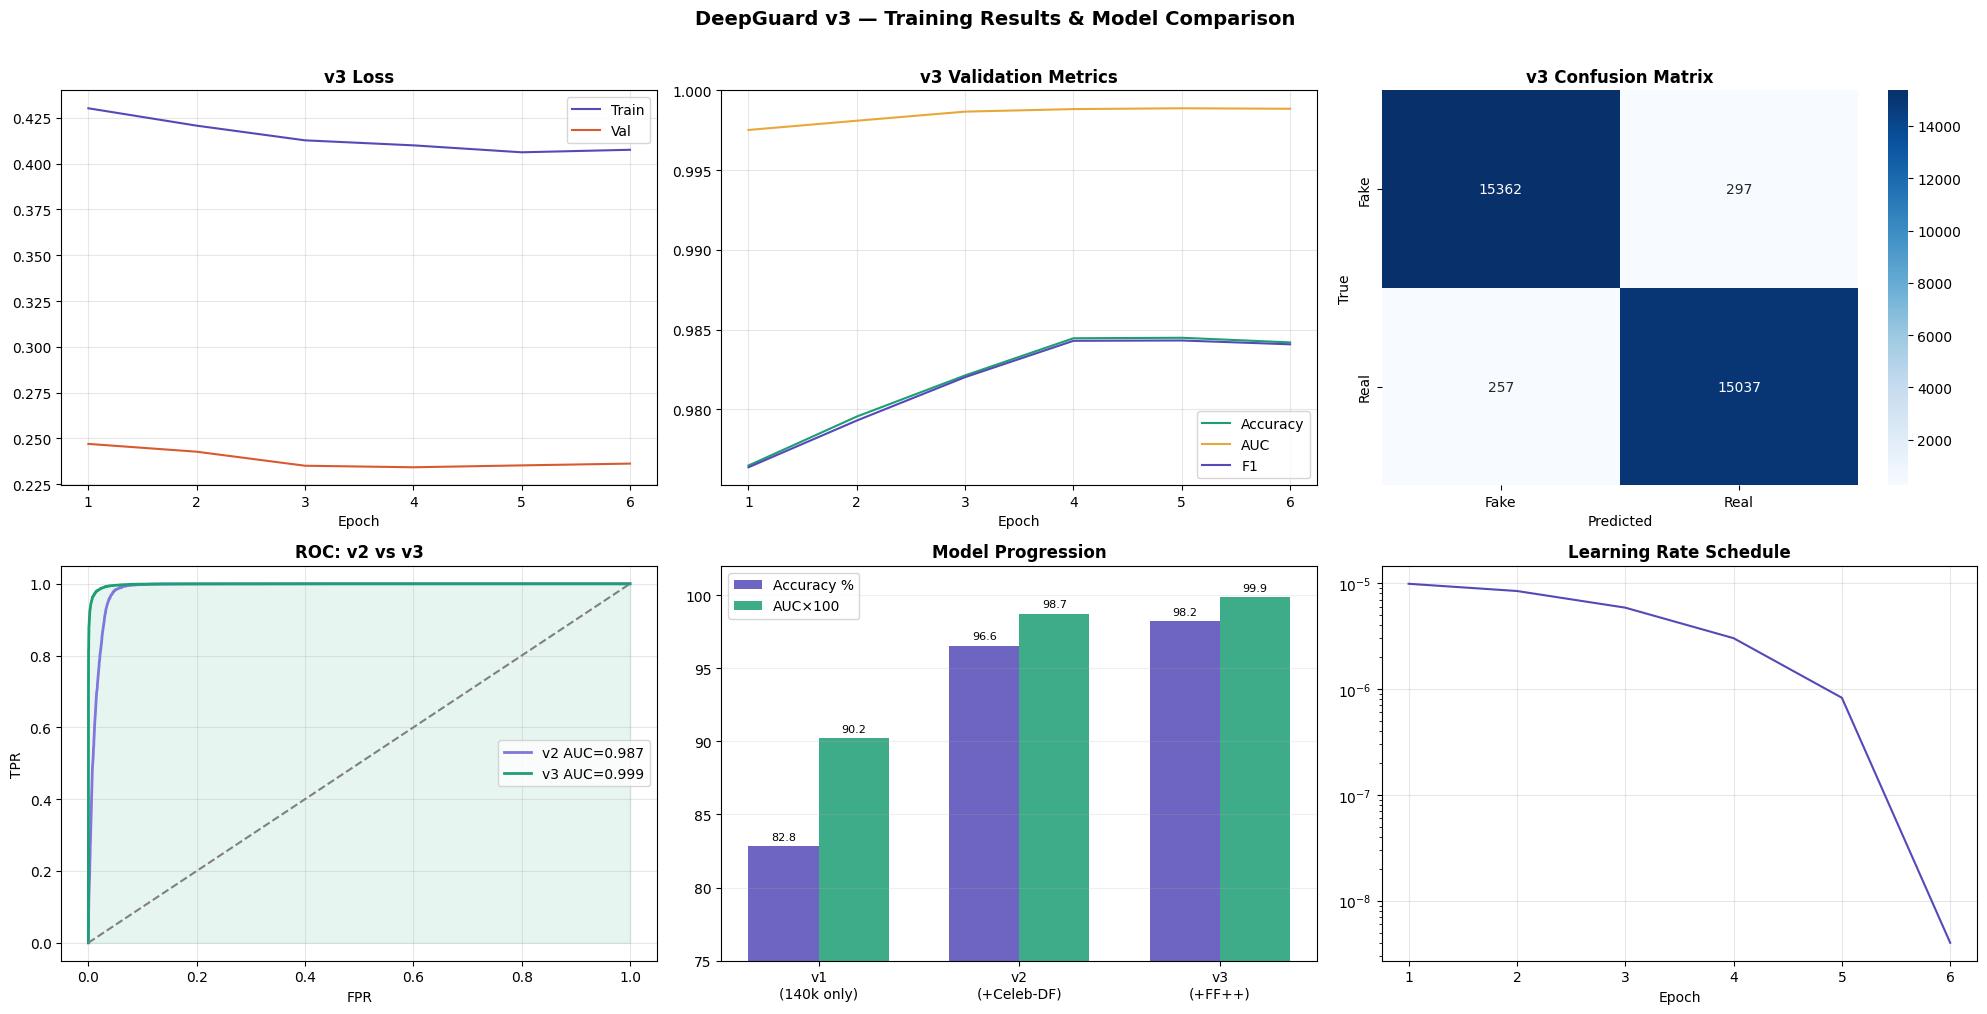

✅ Plots saved to results/v3_full_results.png


In [16]:
with open(HISTORY_FILE) as f:
    history = json.load(f)

fig = plt.figure(figsize=(20, 10))

# 1. Loss curves
ax1 = fig.add_subplot(2,3,1)
ax1.plot(history['epoch'], history['train_loss'], label='Train', color='#534AB7')
ax1.plot(history['epoch'], history['val_loss'],   label='Val',   color='#D85A30')
ax1.set_title('v3 Loss', fontweight='bold'); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_xlabel('Epoch')

# 2. Metrics
ax2 = fig.add_subplot(2,3,2)
ax2.plot(history['epoch'], history['val_acc'], label='Accuracy', color='#1D9E75')
ax2.plot(history['epoch'], history['val_auc'], label='AUC',      color='#E8A838')
ax2.plot(history['epoch'], history['val_f1'],  label='F1',       color='#534AB7')
ax2.set_title('v3 Validation Metrics', fontweight='bold'); ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_xlabel('Epoch')

# 3. Confusion matrix
ax3 = fig.add_subplot(2,3,3)
cm = confusion_matrix(v3_results['labels'], v3_results['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake','Real'], yticklabels=['Fake','Real'], ax=ax3)
ax3.set_title('v3 Confusion Matrix', fontweight='bold')
ax3.set_ylabel('True'); ax3.set_xlabel('Predicted')

# 4. ROC curves (v2 vs v3)
ax4 = fig.add_subplot(2,3,4)
fpr2, tpr2, _ = roc_curve(v2_results['labels'], v2_results['probs'])
fpr3, tpr3, _ = roc_curve(v3_results['labels'], v3_results['probs'])
ax4.plot(fpr2, tpr2, color='#7F77DD', lw=2, label=f'v2 AUC={v2_results["auc"]:.3f}')
ax4.plot(fpr3, tpr3, color='#1D9E75', lw=2, label=f'v3 AUC={v3_results["auc"]:.3f}')
ax4.fill_between(fpr3, tpr3, alpha=0.1, color='#1D9E75')
ax4.plot([0,1],[0,1],'--', color='gray'); ax4.legend()
ax4.set_title('ROC: v2 vs v3', fontweight='bold')
ax4.set_xlabel('FPR'); ax4.set_ylabel('TPR'); ax4.grid(alpha=0.3)

# 5. Bar comparison: v1 vs v2 vs v3
ax5 = fig.add_subplot(2,3,5)
models = ['v1\n(140k only)', 'v2\n(+Celeb-DF)', 'v3\n(+FF++)']
accs   = [82.85, v2_results['acc']*100, v3_results['acc']*100]
aucs   = [90.23, v2_results['auc']*100, v3_results['auc']*100]
x = range(len(models))
w = 0.35
bars1 = ax5.bar([i-w/2 for i in x], accs, w, label='Accuracy %', color='#534AB7', alpha=0.85)
bars2 = ax5.bar([i+w/2 for i in x], aucs, w, label='AUC×100', color='#1D9E75', alpha=0.85)
ax5.set_xticks(list(x)); ax5.set_xticklabels(models)
ax5.set_ylim(75, 102); ax5.legend(); ax5.grid(alpha=0.2, axis='y')
ax5.set_title('Model Progression', fontweight='bold')
for bar in bars1: ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars2: ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

# 6. Learning rate schedule
ax6 = fig.add_subplot(2,3,6)
ax6.plot(history['epoch'], history['lr'], color='#534AB7')
ax6.set_title('Learning Rate Schedule', fontweight='bold')
ax6.set_yscale('log'); ax6.grid(alpha=0.3)
ax6.set_xlabel('Epoch')

plt.suptitle('DeepGuard v3 — Training Results & Model Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v3_full_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plots saved to results/v3_full_results.png')

## ✅ Cell 16 — Export v3 Final Model & Download

In [17]:
export_path = os.path.join(MODEL_DIR, 'deepfake_detector_v3_final.pth')

torch.save({
    'model_state'  : best_ckpt['model_state'],
    'architecture' : 'DualBranchDeepfakeDetector',
    'backbone'     : 'efficientnet_b4',
    'num_classes'  : 2,
    'img_size'     : 224,
    'val_auc'      : best_ckpt['val_auc'],
    'val_acc'      : best_ckpt['val_acc'],
    'trained_epoch': best_ckpt['epoch'],
    'class_names'  : ['fake', 'real'],
    'training_data': '140k Real/Fake + Celeb-DF v2 + FaceForensics++ (combined)',
    'datasets_used': ['140k-real-and-fake-faces', 'celeb-df-v2', 'faceforensics++'],
    'manipulation_types_covered': [
        'GAN-generated (StyleGAN)', 'Face-swap (Celeb-DF)',
        'Deepfakes', 'Face2Face', 'FaceSwap', 'NeuralTextures'
    ],
    'test_auc_combined': v3_results['auc'],
    'test_acc_combined': v3_results['acc'],
}, export_path)

size_mb = os.path.getsize(export_path)/1e6
print(f'✅ v3 model exported!')
print(f'   Path       : {export_path}')
print(f'   Size       : {size_mb:.1f} MB')
print(f'   Val AUC    : {best_ckpt["val_auc"]:.4f}')
print(f'   Val Acc    : {best_ckpt["val_acc"]*100:.2f}%')
print(f'   Test AUC   : {v3_results["auc"]:.4f} (combined test set)')
print(f'   Test Acc   : {v3_results["acc"]*100:.2f}% (combined test set)')
print(f'   Trained on : 140k + Celeb-DF + FF++ ({len(train_ds):,} training images)')
print()

# Zip everything and download
import shutil
shutil.make_archive('/kaggle/working/v3_outputs', 'zip', '/kaggle/working')
print('✅ All outputs zipped!')

from IPython.display import FileLink
print('Click to download:')
display(FileLink('models/deepfake_detector_v3_final.pth'))  # model only
display(FileLink('v3_outputs.zip'))                          # everything

✅ v3 model exported!
   Path       : /kaggle/working/models/deepfake_detector_v3_final.pth
   Size       : 75.6 MB
   Val AUC    : 0.9989
   Val Acc    : 98.45%
   Test AUC   : 0.9986 (combined test set)
   Test Acc   : 98.21% (combined test set)
   Trained on : 140k + Celeb-DF + FF++ (187,624 training images)

✅ All outputs zipped!
Click to download:


/kaggle/working/models/deepfake_detector_v3_final.pth

/kaggle/working/v3_outputs.zip